In [1]:
from lcdb.db import LCDB
from lcdb.analysis import LearningCurveExtractor
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from lcdb.analysis import merge_curves
import pandas as pd
from lcdb.analysis import LearningCurveGroup

import tqdm
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [2]:
import h5py

with h5py.File('LCDB11_ER_265_24.hdf5', 'r') as f:
    dataset_lcdb11 = f['error rate'][...]

In [3]:
learner_zoo = [ 'SVM_Linear', 'SVM_Poly', 'SVM_RBF', 'SVM_Sigmoid', 'Decision Tree', 'ExtraTree','LogisticRegression', 'PassiveAggressive', 'Perceptron', 'RidgeClassifier', 'SGDClassifier', 'MLP', 'LDA', 'QDA', 'BernoulliNB', 'MultinomialNB', 'ComplementNB', 'GaussianNB','KNN', 'NearestCentroid', 'ens.ExtraTrees', 'ens.RandomForest', 'ens.GradientBoosting','DummyClassifier']
dataset_ids_FULL = [3, 6, 11, 12, 13, 14, 15, 16, 18, 21, 22, 23, 24, 26, 28, 29, 30, 31, 32, 36, 37, 38, 44, 46, 50, 54, 55, 57, 60, 61, 151, 179, 180, 181, 182, 184, 185, 188, 201, 273, 293, 299, 300, 307, 336, 346, 351, 354, 357, 380, 389, 390, 391, 392, 393, 395, 396, 398, 399, 401, 446, 458, 469, 554, 679, 715, 718, 720, 722, 723, 727, 728, 734, 735, 737, 740, 741, 743, 751, 752, 761, 772, 797, 799, 803, 806, 807, 813, 816, 819, 821, 822, 823, 833, 837, 843, 845, 846, 847, 849, 866, 871, 881, 897, 901, 903, 904, 910, 912, 913, 914, 917, 923, 930, 934, 953, 958, 959, 962, 966, 971, 976, 977, 978, 979, 980, 991, 993, 995, 1000, 1002, 1018, 1019, 1020, 1021, 1036, 1040, 1041, 1042, 1049, 1050, 1053, 1056, 1063, 1067, 1068, 1069, 1083, 1084, 1085, 1086, 1087, 1088, 1116, 1119, 1120, 1128, 1130, 1134, 1138, 1139, 1142, 1146, 1161, 1166, 1216, 1233, 1235, 1236, 1441, 1448, 1450, 1457, 1461, 1462, 1464, 1465, 1468, 1475, 1477, 1478, 1479, 1480, 1483, 1485, 1486, 1487, 1488, 1489, 1494, 1497, 1499, 1501, 1503, 1509, 1510, 1515, 1566, 1567, 1575, 1590, 1592, 1597, 4134, 4135, 4137, 4534, 4538, 4541, 6332, 23381, 23512, 23517, 40498, 40499, 40664, 40668, 40670, 40672, 40677, 40685, 40687, 40701, 40713, 40900, 40910, 40923, 40927, 40966, 40971, 40975, 40978, 40979, 40981, 40982, 40983, 40984, 40994, 40996, 41027, 41142, 41143, 41144, 41145, 41146, 41150, 41156, 41157, 41158, 41159, 41161, 41163, 41164, 41165, 41166, 41167, 41168, 41169, 41228, 41972, 42734, 42742, 42769, 42809, 42810]


In [4]:
# read the csv datasets.csv 
temp = pd.read_csv('datasets.csv', header=None)
datasets_to_analyze = temp[0].to_numpy()

In [5]:
workflows = pd.read_csv('workflows.csv', header=None)
workflows = workflows[0].to_numpy()
workflows

array(['lcdb.workflow.sklearn.KNNWorkflow',
       'lcdb.workflow.sklearn.LibLinearWorkflow',
       'lcdb.workflow.sklearn.LibSVMWorkflow',
       'lcdb.workflow.sklearn.TreesEnsembleWorkflow',
       'lcdb.workflow.xgboost.XGBoostWorkflow'], dtype=object)

In [6]:
import tqdm

for dataset in tqdm.tqdm(datasets_to_analyze):
    for workflow in [workflows[0], workflows[1], workflows[2]]:
        try:
            # Prepare output filename
            filename_base = f"{workflow.split('.')[-1]}{dataset}"
            log_filename = f"{filename_base}.txt"
            img_filename = f"{filename_base}.png"

            # Redirect stdout to log file
            original_stdout = sys.stdout
            os.makedirs("logs", exist_ok=True)
            with open(os.path.join("logs", log_filename), 'w') as f:
                sys.stdout = f  # Redirect print to file

                lcdb = LCDB()

                df_full = lcdb.query(
                    workflows=[workflow],
                    campaigns=['pre-config-100'],
                    openmlids=[dataset],
                    return_generator=False,
                    processors={
                        "learning_curve": LearningCurveExtractor(
                            metrics=["error_rate"],
                            folds=["val"]
                        )
                    },
                    show_progress=False
                )

                # Remove empty curves
                df_valid = df_full[df_full["learning_curve"].notnull()]
                df_1dataset = df_valid
                config_cols = [c for c in df_1dataset.columns if c.startswith("p:")]
                df = df_1dataset

                learner_cols = [col for col in df.columns if col.startswith('p:') and not col.startswith('p:pp@')]
                preproc_cols = [col for col in df.columns if col.startswith('p:pp@')]

                # Find the most common learner configuration
                default_learner = (
                    df[learner_cols]
                    .value_counts()
                    .idxmax()
                )

                # Find the most common preprocessor configuration
                default_preproc = (
                    df[preproc_cols]
                    .value_counts()
                    .idxmax()
                )

                # Convert to Series for nice formatting
                default_learner_series = pd.Series(default_learner, index=learner_cols)
                default_preproc_series = pd.Series(default_preproc, index=preproc_cols)

                # Print results
                print("Default Learner Hyperparameters:")
                print(default_learner_series)

                print("\nDefault Preprocessor Hyperparameters:")
                print(default_preproc_series)

                # Indicate in dataframe
                df.loc[:, 'uses_default_learner'] = (df[learner_cols] == default_learner_series).all(axis=1).astype(int)
                df.loc[:, 'uses_default_preprocessor'] = (df[preproc_cols] == default_preproc_series).all(axis=1).astype(int)

                config_cols.append('uses_default_learner')
                config_cols.append('uses_default_preprocessor')

                # Merge curves
                df_grouped = df.groupby(config_cols).agg({"learning_curve": merge_curves})

                default_learner_list = []
                default_preprocessor_list = []

                for G in df.groupby(config_cols):
                    uses_default_learner = G[0][-1]
                    uses_default_preprocessor = G[0][-2]

                    default_learner_list.append(uses_default_learner)
                    default_preprocessor_list.append(uses_default_preprocessor)

                # Make a numpy array
                lcg = LearningCurveGroup(df_grouped["learning_curve"])
                lc_list = [lc for lc in lcg]
                lcs = np.concatenate(lc_list)
                lcs2 = np.squeeze(lcs)

                # Make array to indicate type of curve
                default_learner = np.array(default_learner_list)
                default_preprocessor = np.array(default_preprocessor_list)

                default_learner_only = (default_learner == 1) & (default_preprocessor == 0)
                default_preprocessor_only = (default_learner == 0) & (default_preprocessor == 1)

                default_both = (default_learner & default_preprocessor)
                default_either = (default_learner | default_preprocessor)
                no_default = default_either == 0

                # Display counts
                learner_default_count = np.sum(default_learner_only)
                preprocessor_default_count = np.sum(default_preprocessor_only)
                both_default_count = np.sum(default_both)
                no_default_count = np.sum(no_default)

                print(f"Default Learner count: {learner_default_count}")
                print(f"Default Preprocessor count: {preprocessor_default_count}")
                print(f"Both Default count: {both_default_count}")
                print(f"No Default count: {no_default_count}")
                total = learner_default_count + preprocessor_default_count + both_default_count + no_default_count
                print(f"Total: {total}")

                # Default Learner group
                learner_rows = lcs2[default_learner == 1, :]
                learner_default_count = learner_rows.shape[0]
                learner_nan_count = np.isnan(learner_rows).all(axis=1).sum()

                # Default Preprocessor group
                preprocessor_rows = lcs2[default_preprocessor == 1, :]
                preprocessor_default_count = preprocessor_rows.shape[0]
                preprocessor_nan_count = np.isnan(preprocessor_rows).all(axis=1).sum()

                # Both Default group
                both_rows = lcs2[default_both == 1, :]
                both_default_count = both_rows.shape[0]
                both_nan_count = np.isnan(both_rows).all(axis=1).sum()

                # No Default group
                no_default_rows = lcs2[no_default == 1, :]
                no_default_count = no_default_rows.shape[0]
                no_nan_count = np.isnan(no_default_rows).all(axis=1).sum()

                # Print summary
                print(f"OpenML ID: {dataset}")
                print(f"Default Learner count: {learner_default_count} (NaN curves: {learner_nan_count})")
                print(f"Default Preprocessor count: {preprocessor_default_count} (NaN curves: {preprocessor_nan_count})")
                print(f"Both Default count: {both_default_count} (NaN curves: {both_nan_count})")
                print(f"No Default count: {no_default_count} (NaN curves: {no_nan_count})")

            # Always restore original stdout
            sys.stdout = original_stdout

            # Plotting (no redirection here; only file saving)
            alpha = 0.1
            fig, axs = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)

            # Group settings with display labels
            group_configs = [
                (lcs2[default_learner == 1, :], 'blue', workflow, axs[0, 0]),
                (lcs2[default_preprocessor == 1, :], 'orange', dataset, axs[0, 1]),
                (lcs2[no_default == 1, :], 'red', '', axs[1, 0]),
                (lcs2[default_both == 1, :], 'purple', '', axs[1, 1]),
            ]

            # Overlay "All Default HPS"
            both_data = lcs2[default_both == 1, :]
            both_color = 'black'
            both_label = 'All Default HPS (Reference)'

            for data, color, title, ax in group_configs:
                for row in data:
                    ax.plot(row.T, color=color, alpha=alpha)
                for row in both_data:
                    ax.plot(row.T, color=both_color, alpha=1.0)
                ax.set_title(title)

            for i in range(2):
                axs[1, i].set_xlabel("Anchor")
                axs[i, 0].set_ylabel("Error rate")

            legend_elements = [
                Line2D([0], [0], color='blue', lw=2, label='Learner Default HPS'),
                Line2D([0], [0], color='orange', lw=2, label='Preprocessor Default HPS'),
                Line2D([0], [0], color='red', lw=2, label='No Defaults'),
                Line2D([0], [0], color='black', lw=2, label='All Default HPS (Reference)'),
            ]

            ind_dataset = None
            if dataset in dataset_ids_FULL:
                ind_dataset = dataset_ids_FULL.index(dataset)

                for learner_index in [0,1,2,3,23,18]:

                    mean_curve = np.nanmean(dataset_lcdb11[ind_dataset, learner_index, :, :, :, 1, 2, 0], axis=(0, 1))
                    leg_eg_tmp = plt.plot(mean_curve[::4],label='cow')
                    leg_eg = Line2D([0], [0], color=leg_eg_tmp[0].get_color(), lw=2, label=learner_zoo[learner_index])
                    legend_elements.append(leg_eg)

            axs[1, 1].legend(handles=legend_elements, loc='upper right', frameon=True)

            plt.tight_layout()
            os.makedirs("plots", exist_ok=True)
            plt.savefig(os.path.join("plots", img_filename))
            plt.close()

        except Exception as e:
            # Log exception if needed
            sys.stdout = original_stdout
            print(f"Error with dataset {dataset}, workflow {workflow}: {e}")


  0%|          | 0/71 [00:00<?, ?it/s]/tmp/ipykernel_46577/3350373040.py:188: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(dataset_lcdb11[ind_dataset, learner_index, :, :, :, 1, 2, 0], axis=(0, 1))
/tmp/ipykernel_46577/3350373040.py:188: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(dataset_lcdb11[ind_dataset, learner_index, :, :, :, 1, 2, 0], axis=(0, 1))
/tmp/ipykernel_46577/3350373040.py:188: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(dataset_lcdb11[ind_dataset, learner_index, :, :, :, 1, 2, 0], axis=(0, 1))
  1%|▏         | 1/71 [00:06<07:12,  6.18s/it]/tmp/ipykernel_46577/3350373040.py:68: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'uses_default_learner'] = (df[learner_cols] ==

Error with dataset 1596, workflow lcdb.workflow.sklearn.LibSVMWorkflow: 


/tmp/ipykernel_46577/3350373040.py:68: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'uses_default_learner'] = (df[learner_cols] == default_learner_series).all(axis=1).astype(int)
/tmp/ipykernel_46577/3350373040.py:69: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'uses_default_preprocessor'] = (df[preproc_cols] == default_preproc_series).all(axis=1).astype(int)
/tmp/ipykernel_46577/3350373040.py:188: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(dataset_lcdb11[ind_datase

Error with dataset 23517, workflow lcdb.workflow.sklearn.LibSVMWorkflow: 


/tmp/ipykernel_46577/3350373040.py:188: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(dataset_lcdb11[ind_dataset, learner_index, :, :, :, 1, 2, 0], axis=(0, 1))
/tmp/ipykernel_46577/3350373040.py:188: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(dataset_lcdb11[ind_dataset, learner_index, :, :, :, 1, 2, 0], axis=(0, 1))
/tmp/ipykernel_46577/3350373040.py:188: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(dataset_lcdb11[ind_dataset, learner_index, :, :, :, 1, 2, 0], axis=(0, 1))
 42%|████▏     | 30/71 [02:15<02:57,  4.32s/it]/tmp/ipykernel_46577/3350373040.py:68: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'uses_default_learner'] = (df[learner_cols] == default_learner_series).all(axis=1).

...

Error with dataset 42746, workflow lcdb.workflow.sklearn.LibSVMWorkflow: index 0 is out of bounds for axis 0 with size 0


/tmp/ipykernel_46577/3350373040.py:68: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'uses_default_learner'] = (df[learner_cols] == default_learner_series).all(axis=1).astype(int)
/tmp/ipykernel_46577/3350373040.py:69: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'uses_default_preprocessor'] = (df[preproc_cols] == default_preproc_series).all(axis=1).astype(int)
/tmp/ipykernel_46577/3350373040.py:188: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(dataset_lcdb11[ind_datase

Error with dataset 43072, workflow lcdb.workflow.sklearn.KNNWorkflow: index 0 is out of bounds for axis 0 with size 0
Error with dataset 43072, workflow lcdb.workflow.sklearn.LibLinearWorkflow: index 0 is out of bounds for axis 0 with size 0


100%|██████████| 71/71 [05:46<00:00,  4.88s/it]

Error with dataset 43072, workflow lcdb.workflow.sklearn.LibSVMWorkflow: index 0 is out of bounds for axis 0 with size 0


In [7]:

num = 1
for dataset in datasets_to_analyze:
    if dataset in dataset_ids_FULL:
        print(dataset)
        num = num+1

3
12
23
31
54
181
188
1049
1067
1457
1461
1464
1468
1475
1486
1487
1489
1494
1515
1590
4134
4135
4534
4538
4541
23517
40498
40668
40670
40685
40701
40900
40975
40978
40981
40982
40983
40984
40996
41027
41142
41143
41144
41145
41146
41150
41156
41157
41158
41159
41161
41163
41164
41165
41166
41167
41168
41169
42734
42742
42769


In [8]:
num

62

In [9]:
dataset = 3
workflow

'lcdb.workflow.sklearn.LibSVMWorkflow'

/tmp/ipykernel_46577/3579990023.py:183: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(dataset_lcdb11[ind_dataset, learner_index, :, :, :, 1, 2, 0], axis=(0, 1))


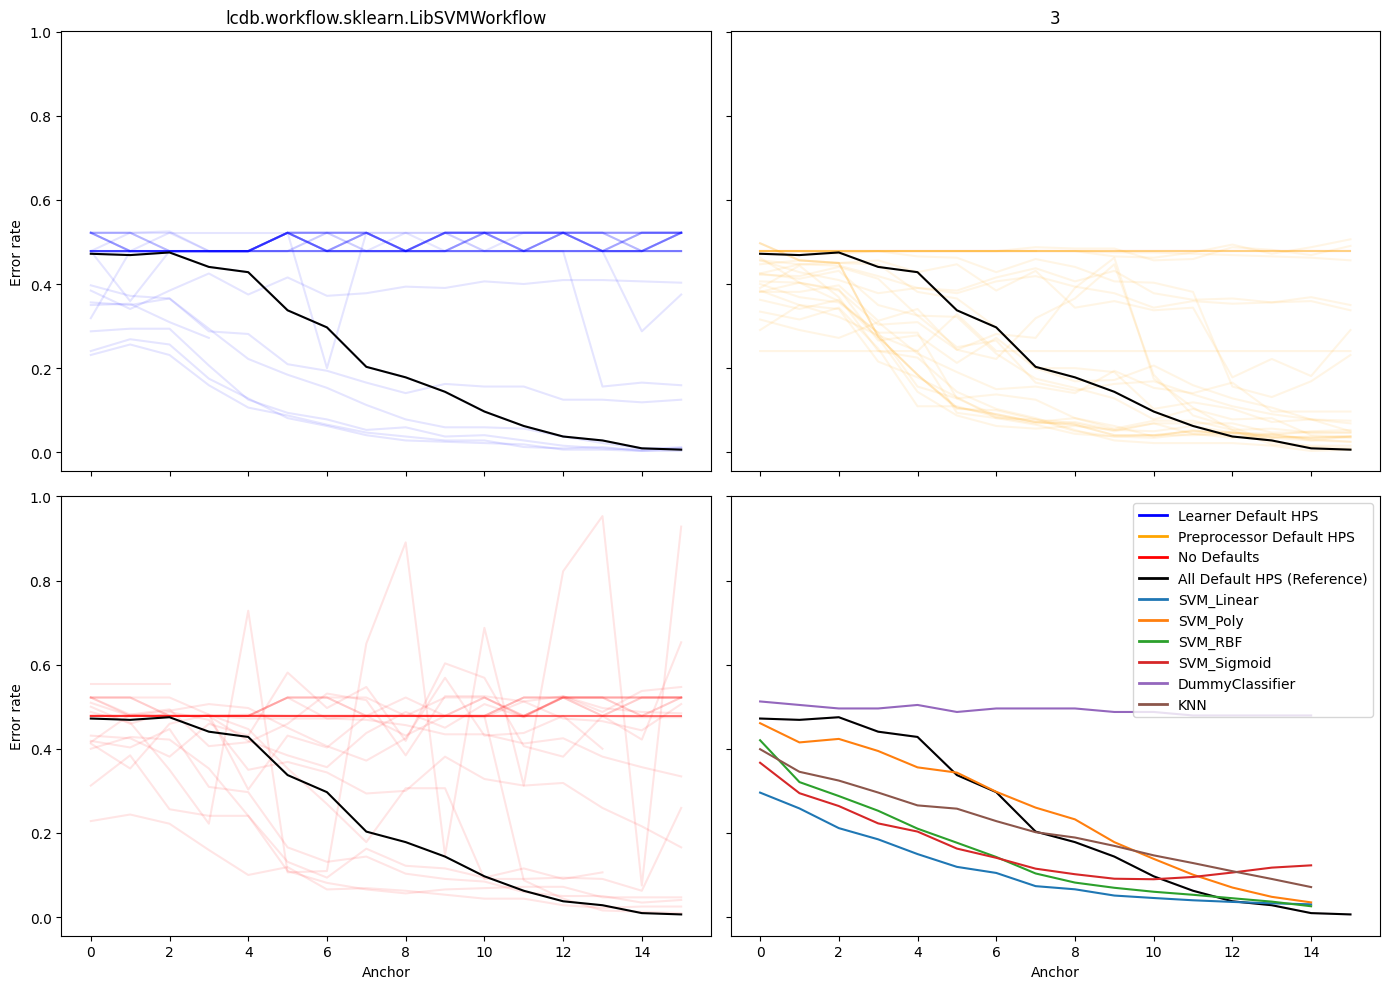

In [10]:
# Prepare output filename
filename_base = f"{workflow.split('.')[-1]}{dataset}"
log_filename = f"{filename_base}.txt"
img_filename = f"{filename_base}.png"

# Redirect stdout to log file
original_stdout = sys.stdout
os.makedirs("logs", exist_ok=True)
with open(os.path.join("logs", log_filename), 'w') as f:
    sys.stdout = f  # Redirect print to file

    lcdb = LCDB()

    df_full = lcdb.query(
        workflows=[workflow],
        campaigns=['pre-config-100'],
        openmlids=[dataset],
        return_generator=False,
        processors={
            "learning_curve": LearningCurveExtractor(
                metrics=["error_rate"],
                folds=["val"]
            )
        },
        show_progress=False
    )

    # Remove empty curves
    df_valid = df_full[df_full["learning_curve"].notnull()]
    df_1dataset = df_valid
    config_cols = [c for c in df_1dataset.columns if c.startswith("p:")]
    df = df_1dataset

    learner_cols = [col for col in df.columns if col.startswith('p:') and not col.startswith('p:pp@')]
    preproc_cols = [col for col in df.columns if col.startswith('p:pp@')]

    # Find the most common learner configuration
    default_learner = (
        df[learner_cols]
        .value_counts()
        .idxmax()
    )

    # Find the most common preprocessor configuration
    default_preproc = (
        df[preproc_cols]
        .value_counts()
        .idxmax()
    )

    # Convert to Series for nice formatting
    default_learner_series = pd.Series(default_learner, index=learner_cols)
    default_preproc_series = pd.Series(default_preproc, index=preproc_cols)

    # Print results
    print("Default Learner Hyperparameters:")
    print(default_learner_series)

    print("\nDefault Preprocessor Hyperparameters:")
    print(default_preproc_series)

    # Indicate in dataframe
    df.loc[:, 'uses_default_learner'] = (df[learner_cols] == default_learner_series).all(axis=1).astype(int)
    df.loc[:, 'uses_default_preprocessor'] = (df[preproc_cols] == default_preproc_series).all(axis=1).astype(int)

    config_cols.append('uses_default_learner')
    config_cols.append('uses_default_preprocessor')

    # Merge curves
    df_grouped = df.groupby(config_cols).agg({"learning_curve": merge_curves})

    default_learner_list = []
    default_preprocessor_list = []

    for G in df.groupby(config_cols):
        uses_default_learner = G[0][-1]
        uses_default_preprocessor = G[0][-2]

        default_learner_list.append(uses_default_learner)
        default_preprocessor_list.append(uses_default_preprocessor)

    # Make a numpy array
    lcg = LearningCurveGroup(df_grouped["learning_curve"])
    lc_list = [lc for lc in lcg]
    lcs = np.concatenate(lc_list)
    lcs2 = np.squeeze(lcs)

    # Make array to indicate type of curve
    default_learner = np.array(default_learner_list)
    default_preprocessor = np.array(default_preprocessor_list)

    default_learner_only = (default_learner == 1) & (default_preprocessor == 0)
    default_preprocessor_only = (default_learner == 0) & (default_preprocessor == 1)

    default_both = (default_learner & default_preprocessor)
    default_either = (default_learner | default_preprocessor)
    no_default = default_either == 0

    # Display counts
    learner_default_count = np.sum(default_learner_only)
    preprocessor_default_count = np.sum(default_preprocessor_only)
    both_default_count = np.sum(default_both)
    no_default_count = np.sum(no_default)

    print(f"Default Learner count: {learner_default_count}")
    print(f"Default Preprocessor count: {preprocessor_default_count}")
    print(f"Both Default count: {both_default_count}")
    print(f"No Default count: {no_default_count}")
    total = learner_default_count + preprocessor_default_count + both_default_count + no_default_count
    print(f"Total: {total}")

    # Default Learner group
    learner_rows = lcs2[default_learner == 1, :]
    learner_default_count = learner_rows.shape[0]
    learner_nan_count = np.isnan(learner_rows).all(axis=1).sum()

    # Default Preprocessor group
    preprocessor_rows = lcs2[default_preprocessor == 1, :]
    preprocessor_default_count = preprocessor_rows.shape[0]
    preprocessor_nan_count = np.isnan(preprocessor_rows).all(axis=1).sum()

    # Both Default group
    both_rows = lcs2[default_both == 1, :]
    both_default_count = both_rows.shape[0]
    both_nan_count = np.isnan(both_rows).all(axis=1).sum()

    # No Default group
    no_default_rows = lcs2[no_default == 1, :]
    no_default_count = no_default_rows.shape[0]
    no_nan_count = np.isnan(no_default_rows).all(axis=1).sum()

    # Print summary
    print(f"OpenML ID: {dataset}")
    print(f"Default Learner count: {learner_default_count} (NaN curves: {learner_nan_count})")
    print(f"Default Preprocessor count: {preprocessor_default_count} (NaN curves: {preprocessor_nan_count})")
    print(f"Both Default count: {both_default_count} (NaN curves: {both_nan_count})")
    print(f"No Default count: {no_default_count} (NaN curves: {no_nan_count})")

# Always restore original stdout
sys.stdout = original_stdout

# Plotting (no redirection here; only file saving)
alpha = 0.1
fig, axs = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)

# Group settings with display labels
group_configs = [
    (lcs2[default_learner == 1, :], 'blue', workflow, axs[0, 0]),
    (lcs2[default_preprocessor == 1, :], 'orange', dataset, axs[0, 1]),
    (lcs2[no_default == 1, :], 'red', '', axs[1, 0]),
    (lcs2[default_both == 1, :], 'purple', '', axs[1, 1]),
]

# Overlay "All Default HPS"
both_data = lcs2[default_both == 1, :]
both_color = 'black'
both_label = 'All Default HPS (Reference)'

for data, color, title, ax in group_configs:
    for row in data:
        ax.plot(row.T, color=color, alpha=alpha)
    for row in both_data:
        ax.plot(row.T, color=both_color, alpha=1.0)
    ax.set_title(title)

for i in range(2):
    axs[1, i].set_xlabel("Anchor")
    axs[i, 0].set_ylabel("Error rate")

legend_elements = [
    Line2D([0], [0], color='blue', lw=2, label='Learner Default HPS'),
    Line2D([0], [0], color='orange', lw=2, label='Preprocessor Default HPS'),
    Line2D([0], [0], color='red', lw=2, label='No Defaults'),
    Line2D([0], [0], color='black', lw=2, label='All Default HPS (Reference)'),
]

ind_dataset = None
if dataset in dataset_ids_FULL:
    ind_dataset = dataset_ids_FULL.index(dataset)

    for learner_index in [0,1,2,3,23,18]:

        mean_curve = np.nanmean(dataset_lcdb11[ind_dataset, learner_index, :, :, :, 1, 2, 0], axis=(0, 1))
        leg_eg_tmp = plt.plot(mean_curve[::4],label='cow')
        leg_eg = Line2D([0], [0], color=leg_eg_tmp[0].get_color(), lw=2, label=learner_zoo[learner_index])
        legend_elements.append(leg_eg)

axs[1, 1].legend(handles=legend_elements, loc='upper right', frameon=True)

plt.tight_layout()